In [1]:
%pip install pandas

In [2]:
%pip install openpyxl

In [3]:
import pandas as pd

df = pd.read_excel('20~21년 자치구별 연료별 자동차 등록현황.xlsx')

df.head()

,2015년 ~ 2021년도 12월말 기준 시군구별 용도별 차종별 연료별 등록 현황,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,연월,사용본거지시군구,시군구코드,용도,차종종별,연료,건수
1,202012,서울특별시 종로구,11110,관용,승용,휘발유,155
2,202012,서울특별시 종로구,11110,관용,화물,경유,330
3,202012,서울특별시 종로구,11110,관용,화물,기타연료,3
4,202012,서울특별시 종로구,11110,관용,특수,기타연료,2


In [4]:
df.columns

Index(['2015년 ~ 2021년도 12월말 기준 시군구별 용도별 차종별 연료별 등록 현황', 'Unnamed: 1',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [5]:
df.columns = df.iloc[0]
df = df[1:]

In [6]:
df.head()

,연월,사용본거지시군구,시군구코드,용도,차종종별,연료,건수
1,202012,서울특별시 종로구,11110,관용,승용,휘발유,155
2,202012,서울특별시 종로구,11110,관용,화물,경유,330
3,202012,서울특별시 종로구,11110,관용,화물,기타연료,3
4,202012,서울특별시 종로구,11110,관용,특수,기타연료,2
5,202012,서울특별시 종로구,11110,자가용,화물,휘발유,71


In [7]:
#unique 확인
df['연료'].unique()

array(['휘발유', '경유', '기타연료', '엘피지', '전기', '휘발유(무연)', 'CNG', '휘발유(유연)',
       '수소', '하이브리드(휘발유+전기)', '하이브리드(LPG+전기)', '하이브리드(경유+전기)',
       '하이브리드(CNG+전기)'], dtype=object)

In [8]:
ev_df = df[df['연료'] == '전기']
ev_df['연료'].unique()

array(['전기'], dtype=object)

In [9]:
#연도/월 분리
ev_df = df[df['연료'] == '전기'].copy()

ev_df['연도'] = ev_df['연월'].astype(str).str[:4]
ev_df['월'] = ev_df['연월'].astype(str).str[4:]

ev_df.head()

,연월,사용본거지시군구,시군구코드,용도,차종종별,연료,건수,연도,월
8,202012,서울특별시 종로구,11110,영업용,승용,전기,5,2020,12
12,202012,서울특별시 중구,11140,관용,승용,전기,124,2020,12
19,202012,서울특별시 용산구,11170,자가용,승용,전기,412,2020,12
23,202012,서울특별시 용산구,11170,영업용,승용,전기,2,2020,12
49,202012,서울특별시 성동구,11200,자가용,승용,전기,362,2020,12


In [10]:
#차종 구분 합치기
ev_group = ev_df.groupby(
    ['연도', '사용본거지시군구']
)['건수'].sum().reset_index()

ev_group.head()

,연도,사용본거지시군구,건수
0,2020,서울특별시 강남구,7495
1,2020,서울특별시 강동구,649
2,2020,서울특별시 강북구,298
3,2020,서울특별시 강서구,805
4,2020,서울특별시 관악구,412


In [11]:
#컬럼명 정리
ev_group.rename(columns={
    '사용본거지시군구':'자치구',
    '건수':'전기차수'
}, inplace=True)

In [12]:
ev_group['자치구'].nunique()

25

In [13]:
import matplotlib.font_manager as fm

fonts = [f.name for f in fm.fontManager.ttflist]
sorted(set(fonts))[:50]

['DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Humor Sans',
 'STIXGeneral',
 'STIXNonUnicode',
 'STIXSizeFiveSym',
 'STIXSizeFourSym',
 'STIXSizeOneSym',
 'STIXSizeThreeSym',
 'STIXSizeTwoSym',
 'cmb10',
 'cmex10',
 'cmmi10',
 'cmr10',
 'cmss10',
 'cmsy10',
 'cmtt10']

In [16]:
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

font_path = 'malgun.ttf'

fontprop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(fontprop.get_name())

Malgun Gothic


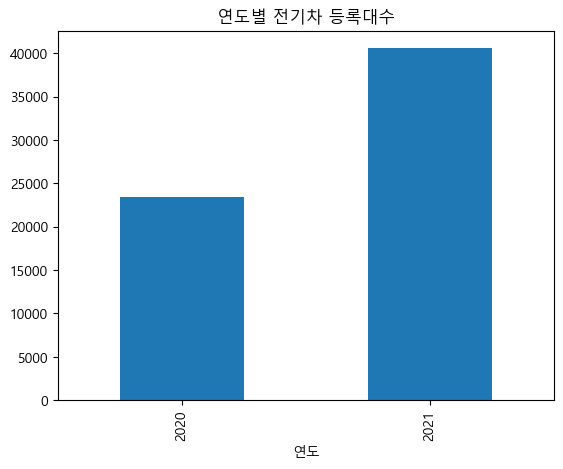

In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'

fm.fontManager.addfont('malgun.ttf')

year_sum = ev_group.groupby('연도')['전기차수'].sum()

year_sum.plot(kind='bar')

plt.title('연도별 전기차 등록대수')
plt.show()

2020 → 2021 사이 전기차 등록대수가 크게 증가

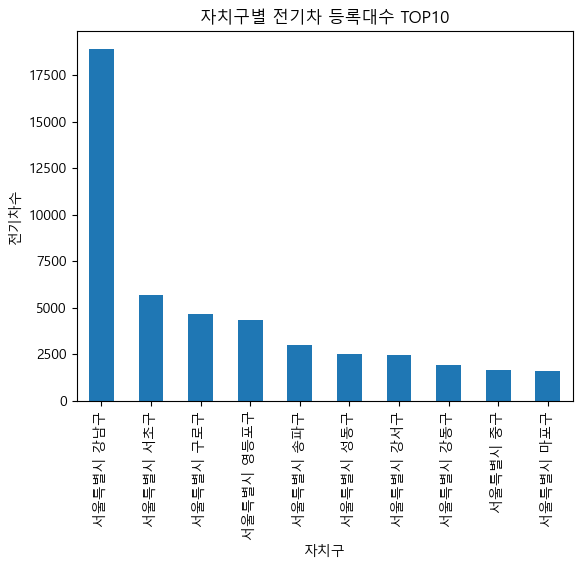

In [20]:
#자치구별 비교 그래프
district_sum = ev_group.groupby('자치구')['전기차수'].sum()

district_sum.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('자치구별 전기차 등록대수 TOP10')

plt.xlabel('자치구')
plt.ylabel('전기차수')

plt.show()

In [21]:
#서울시 소유 전기차 충전소 데이터 불러오기 
charger = pd.read_excel('서울시 소유 전기차 충전소 정보.xlsx')
charger.head()

,운영기관,충전소,충전기ID,충전기타입,시설구분(대),시설구분(소),지역,시군구,주소,이용가능시간,이용자 제한,충전용량,편의제공,비고
0,서울시,50동부캠퍼스,1,AC완속,공공시설,지자체시설,서울특별시,광진구,서울특별시 광진구 능동로3길 66-12 50 동부캠퍼스,24시간 이용가능,NaN,완속(7kW단독),N,NaN
1,서울시,50동부캠퍼스,2,AC완속,공공시설,지자체시설,서울특별시,광진구,서울특별시 광진구 능동로3길 66-12 50 동부캠퍼스,24시간 이용가능,NaN,완속(7kW단독),N,NaN
2,서울시,50동부캠퍼스,3,AC완속,공공시설,지자체시설,서울특별시,광진구,서울특별시 광진구 능동로3길 66-12 50 동부캠퍼스,24시간 이용가능,NaN,완속(7kW단독),N,NaN
3,서울시,50동부캠퍼스,4,AC완속,공공시설,지자체시설,서울특별시,광진구,서울특별시 광진구 능동로3길 66-12 50 동부캠퍼스,24시간 이용가능,NaN,완속(7kW단독),N,NaN
4,서울시,50동부캠퍼스,5,AC완속,공공시설,지자체시설,서울특별시,광진구,서울특별시 광진구 능동로3길 66-12 50 동부캠퍼스,24시간 이용가능,NaN,완속(7kW단독),N,NaN


In [22]:
#컬럼 확인
charger.columns

Index(['운영기관', '충전소', '충전기ID', '충전기타입', '시설구분(대)', '시설구분(소)', '지역', '시군구',
       '주소', '이용가능시간', '이용자 제한', '충전용량', '편의제공', '비고'],
      dtype='object')

In [23]:
#자치구별 충전소 수 집계
charger_group = charger.groupby('시군구').size().reset_index(name='충전소수')
charger_group.head()

,시군구,충전소수
0,강남구,29
1,강동구,11
2,강북구,6
3,강서구,9
4,관악구,8


In [29]:
#서울시 전기차 데이터 정리
ev_group['자치구'] = ev_group['자치구'].str.replace('서울특별시 ', '')

#merge
charger_group.rename(columns={
    '시군구':'자치구'
}, inplace=True)

final_df = pd.merge(
    ev_group,
    charger_group,
    on='자치구'
)

ev_group['자치구'].unique()
charger_group['자치구'].unique()

array(['강남구 ', '강동구 ', '강북구 ', '강서구 ', '관악구 ', '광진구 ', '구로구 ', '금천구 ',
       '노원구 ', '도봉구 ', '동대문구 ', '동작구 ', '마포구 ', '서대문구 ', '서초구 ', '성동구 ',
       '성북구 ', '송파구 ', '안양시 ', '양천구 ', '영등포구 ', '용산구 ', '은평구 ', '종로구 ',
       '중구 ', '중랑구 '], dtype=object)

In [33]:
ev_group['자치구'].unique()[:10]

array(['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
       '도봉구'], dtype=object)

In [34]:
final_df.shape
final_df.head()
final_df.columns

Index(['연도', '자치구', '전기차수', '충전소수'], dtype='object')

In [46]:
charger_group.head()

,자치구,충전소수
0,강남구,29
1,강동구,11
2,강북구,6
3,강서구,9
4,관악구,8


In [47]:
final_df = pd.merge(
    ev_group[ev_group['연도'] == '2021'],
    charger_group,
    on='자치구',
    how='inner'
)

final_df.head()

,연도,자치구,전기차수,충전소수
0,2021,강남구,11432,29
1,2021,강동구,1273,11
2,2021,강북구,496,6
3,2021,강서구,1679,9
4,2021,관악구,730,8


In [43]:
ev_group['연도'].unique()

array(['2020', '2021'], dtype=object)

In [44]:
ev_group['연도'] = ev_group['연도'].astype(str).str.strip()

In [45]:
final_df = pd.merge(
    ev_group[ev_group['연도'] == '2021'],
    charger_group,
    on='자치구',
    how='inner'
)

final_df.shape

(25, 4)

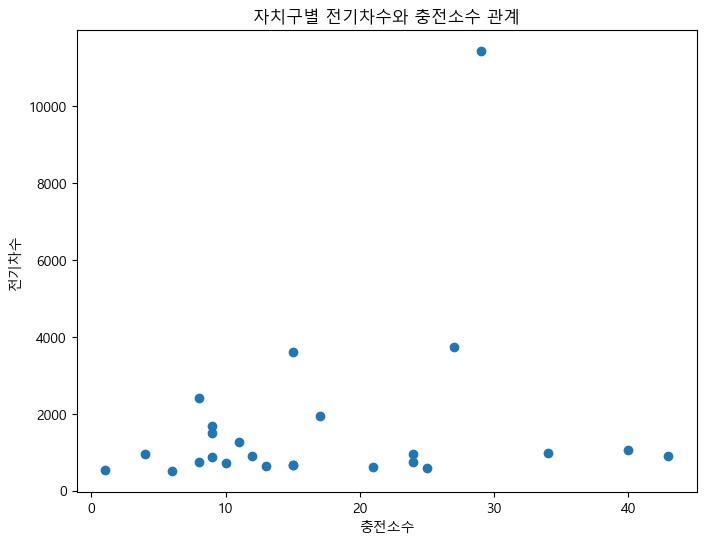

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    final_df['충전소수'],
    final_df['전기차수']
)

plt.xlabel('충전소수')
plt.ylabel('전기차수')
plt.title('자치구별 전기차수와 충전소수 관계')

plt.show()